# 第3章 GPU 体系结构（下）：数据存储与访问

## 本章导读

[上一章](../chapter2/chapter2.ipynb)确定了哪个线程负责哪个位置。本章继续追踪：
输入数组已经在 GPU 上，为什么线程还要等待读取？什么时候需要让两个线程交换数据？
我们先用小数组观察位置，再写一个 block 内交接数据的 HIP kernel。
[对应正文](../../../docs/part0-intro/chapter3/index.md)通过局部和交接解释共享与同步；
这里用邻居加法亲手练习同样的先写后读关系。


In [ ]:
%run ../../common/bootstrap.py

import torch
import hello_gpu as gpu

cfg = gpu.settings()
torch.manual_seed(cfg["seed"])
%load_ext hello_gpu
cfg


## 3.1 数据位置与读写过程

执行 `c[2] = a[2] + b[2]` 时，先从输入数组取得两个值，运算产生临时结果，再把结果写回输出。
全局内存描述输入、输出使用的访问空间；寄存器保存指令当前使用的临时值；执行单元使用这些值计算。
源码变量的数量不等于实际寄存器数量，存放安排由编译器决定。


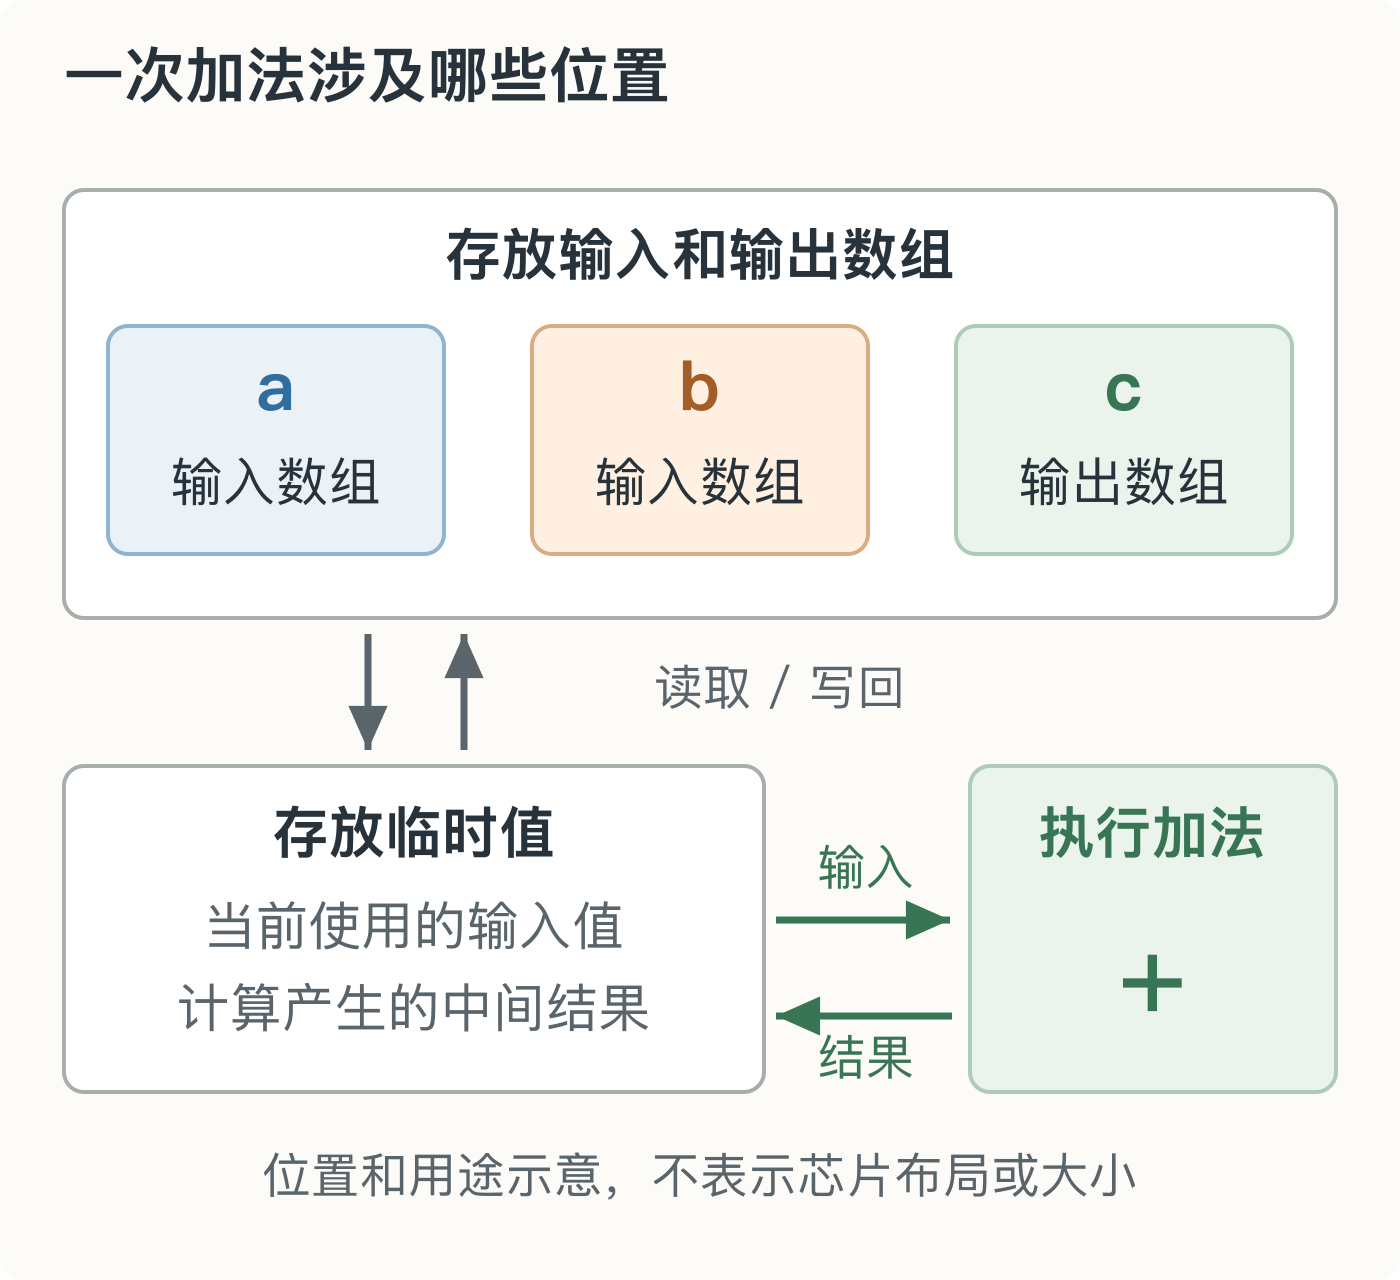

*保存数组、保存临时值和执行运算是三种职责；图不表示芯片面积或真实距离。*


In [ ]:
a = torch.tensor([1., 2., 3., 4.], device="cuda")
b = torch.tensor([10., 20., 30., 40.], device="cuda")
c = torch.empty_like(a)
torch.add(a, b, out=c)
{"a": a.cpu().tolist(), "b": b.cpu().tolist(), "c": c.cpu().tolist()}


**观察**：输入仍然保留，输出获得相加后的值。GPU 写回 `c` 后，数据仍位于 GPU；
这里的 `.cpu()` 才让主机拿到便于查看的副本。它不应悄悄放进我们想测的纯设备侧计算区间。


## 3.2 Wavefront 的访存组织

一次读取面对的是一组 lane 提供的地址。四个 lane 都读一个 FP32 数，连续下标与跨步下标
都只需要四个结果，但覆盖的地址范围可以不同。相邻线程访问相邻元素，通常更有利于硬件合并处理。


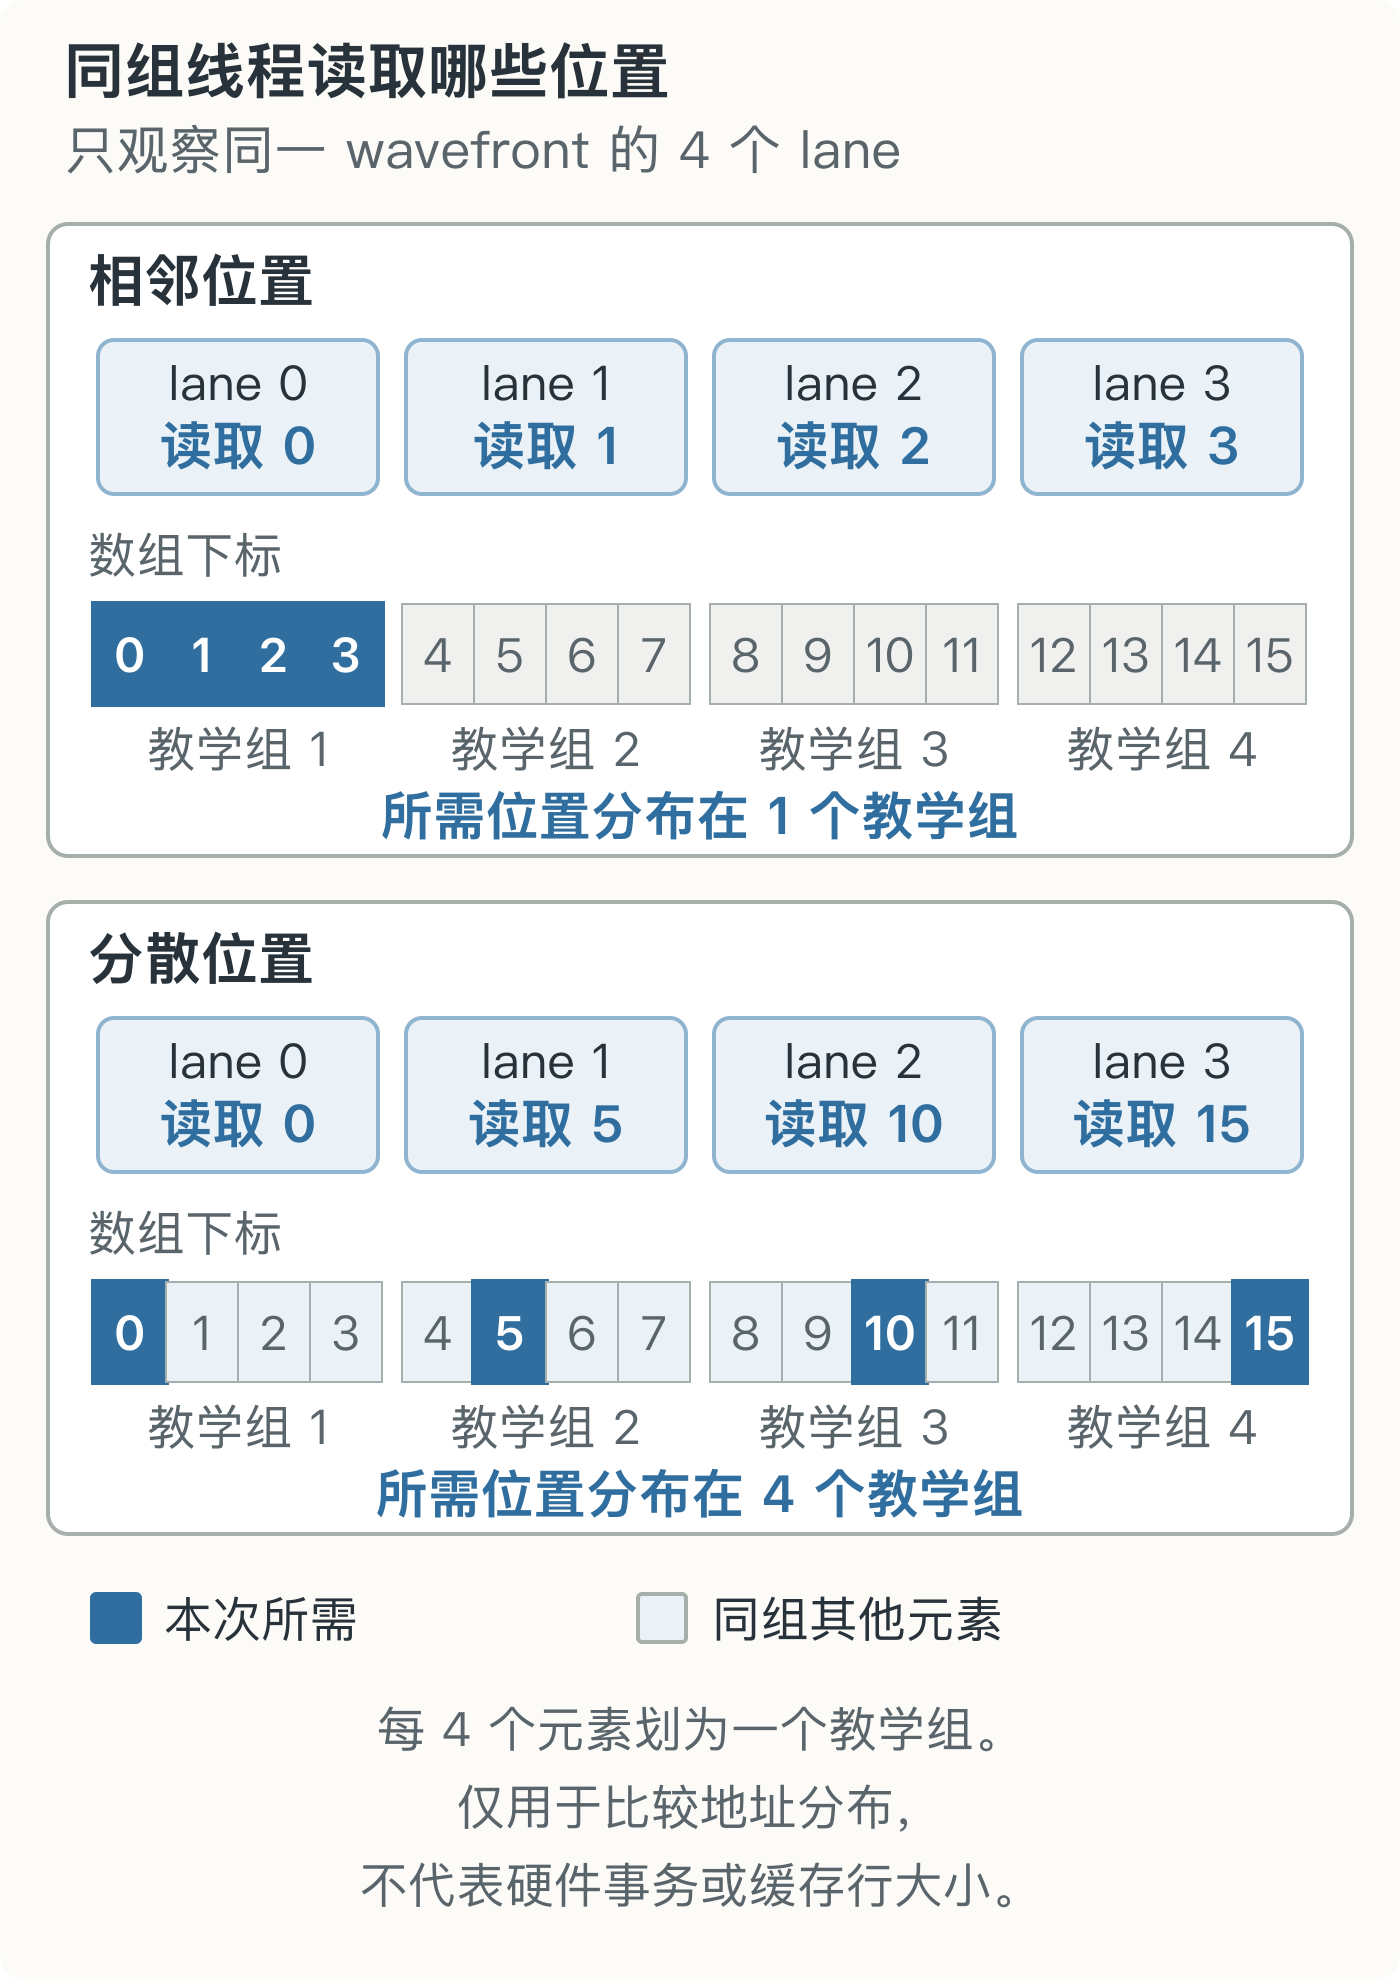

*比较同一批 lane 的地址排列；图中的分组用于教学，不代表固定事务或缓存行大小。*


In [ ]:
import pandas as pd

lanes = list(range(4))
pd.DataFrame({"lane": lanes,
              "连续下标": lanes, "连续字节偏移": [4 * i for i in lanes],
              "跨步下标": [5 * i for i in lanes], "跨步字节偏移": [20 * i for i in lanes]})


**观察**：这里的 4 字节来自 FP32 元素大小，5 来自我们选定的下标步长。
我们没有据此指定硬件做了几次事务。缓存是否已保存数据，也会影响数据从哪里提供。

Tensor 的 `stride` 可以帮助理解地址公式。下面仍在 CPU 上观察同一块存储的两个视图：


In [ ]:
storage = torch.arange(20, dtype=torch.float32)
dense, strided = storage[:4], storage[::5]
pd.DataFrame([{"view": name, "values": value.tolist(), "stride": value.stride(),
               "contiguous": value.is_contiguous()}
              for name, value in (("连续", dense), ("跨步", strided))])


这解释了为什么我们的 `binary_f32` 教学接口要求连续 Tensor：kernel 的 `a[i]` 按连续 FP32
位置前进，不会自动理解 Python 视图的步长。将跨步视图转为连续副本会产生额外工作，
需要明确放在哪个阶段并记录成本。后续逐元素算子章节再用同口径实验比较访存策略。


## 3.3 Block 内的数据共享与同步

普通加法中，每个输出独立。但如果线程要使用邻居加载的值，就需要约定交接位置和交接时刻。
LDS 是同一 block 可使用的共享存储，`__shared__` 声明空间；`__syncthreads()` 建立屏障，
保证屏障前的共享写入在屏障后可被组内线程使用。

我们用邻居加法练习协作：每个 block 内将 `a` 左循环移动一个位置，再与原位置的 `b` 相加。
两幅图采用同一个固定手算例子：`n=6`、`block=4`，输入 `a=[1,2,3,4,5,6]`，
输入 `b=[10,20,30,40,50,60]`。前四个位置组成完整块，后两个位置组成尾块。
这组小数用于追踪数据，后面的规模实验仍使用配置中的 `n` 和 `block`。

**先写自己的位置。**每个有效线程将 `a[i]` 放进自己的 `tile` 位置。
尾块仍有四个线程；没有有效输入的两名线程写入占位值 0，然后和本块其他线程一起到达屏障。


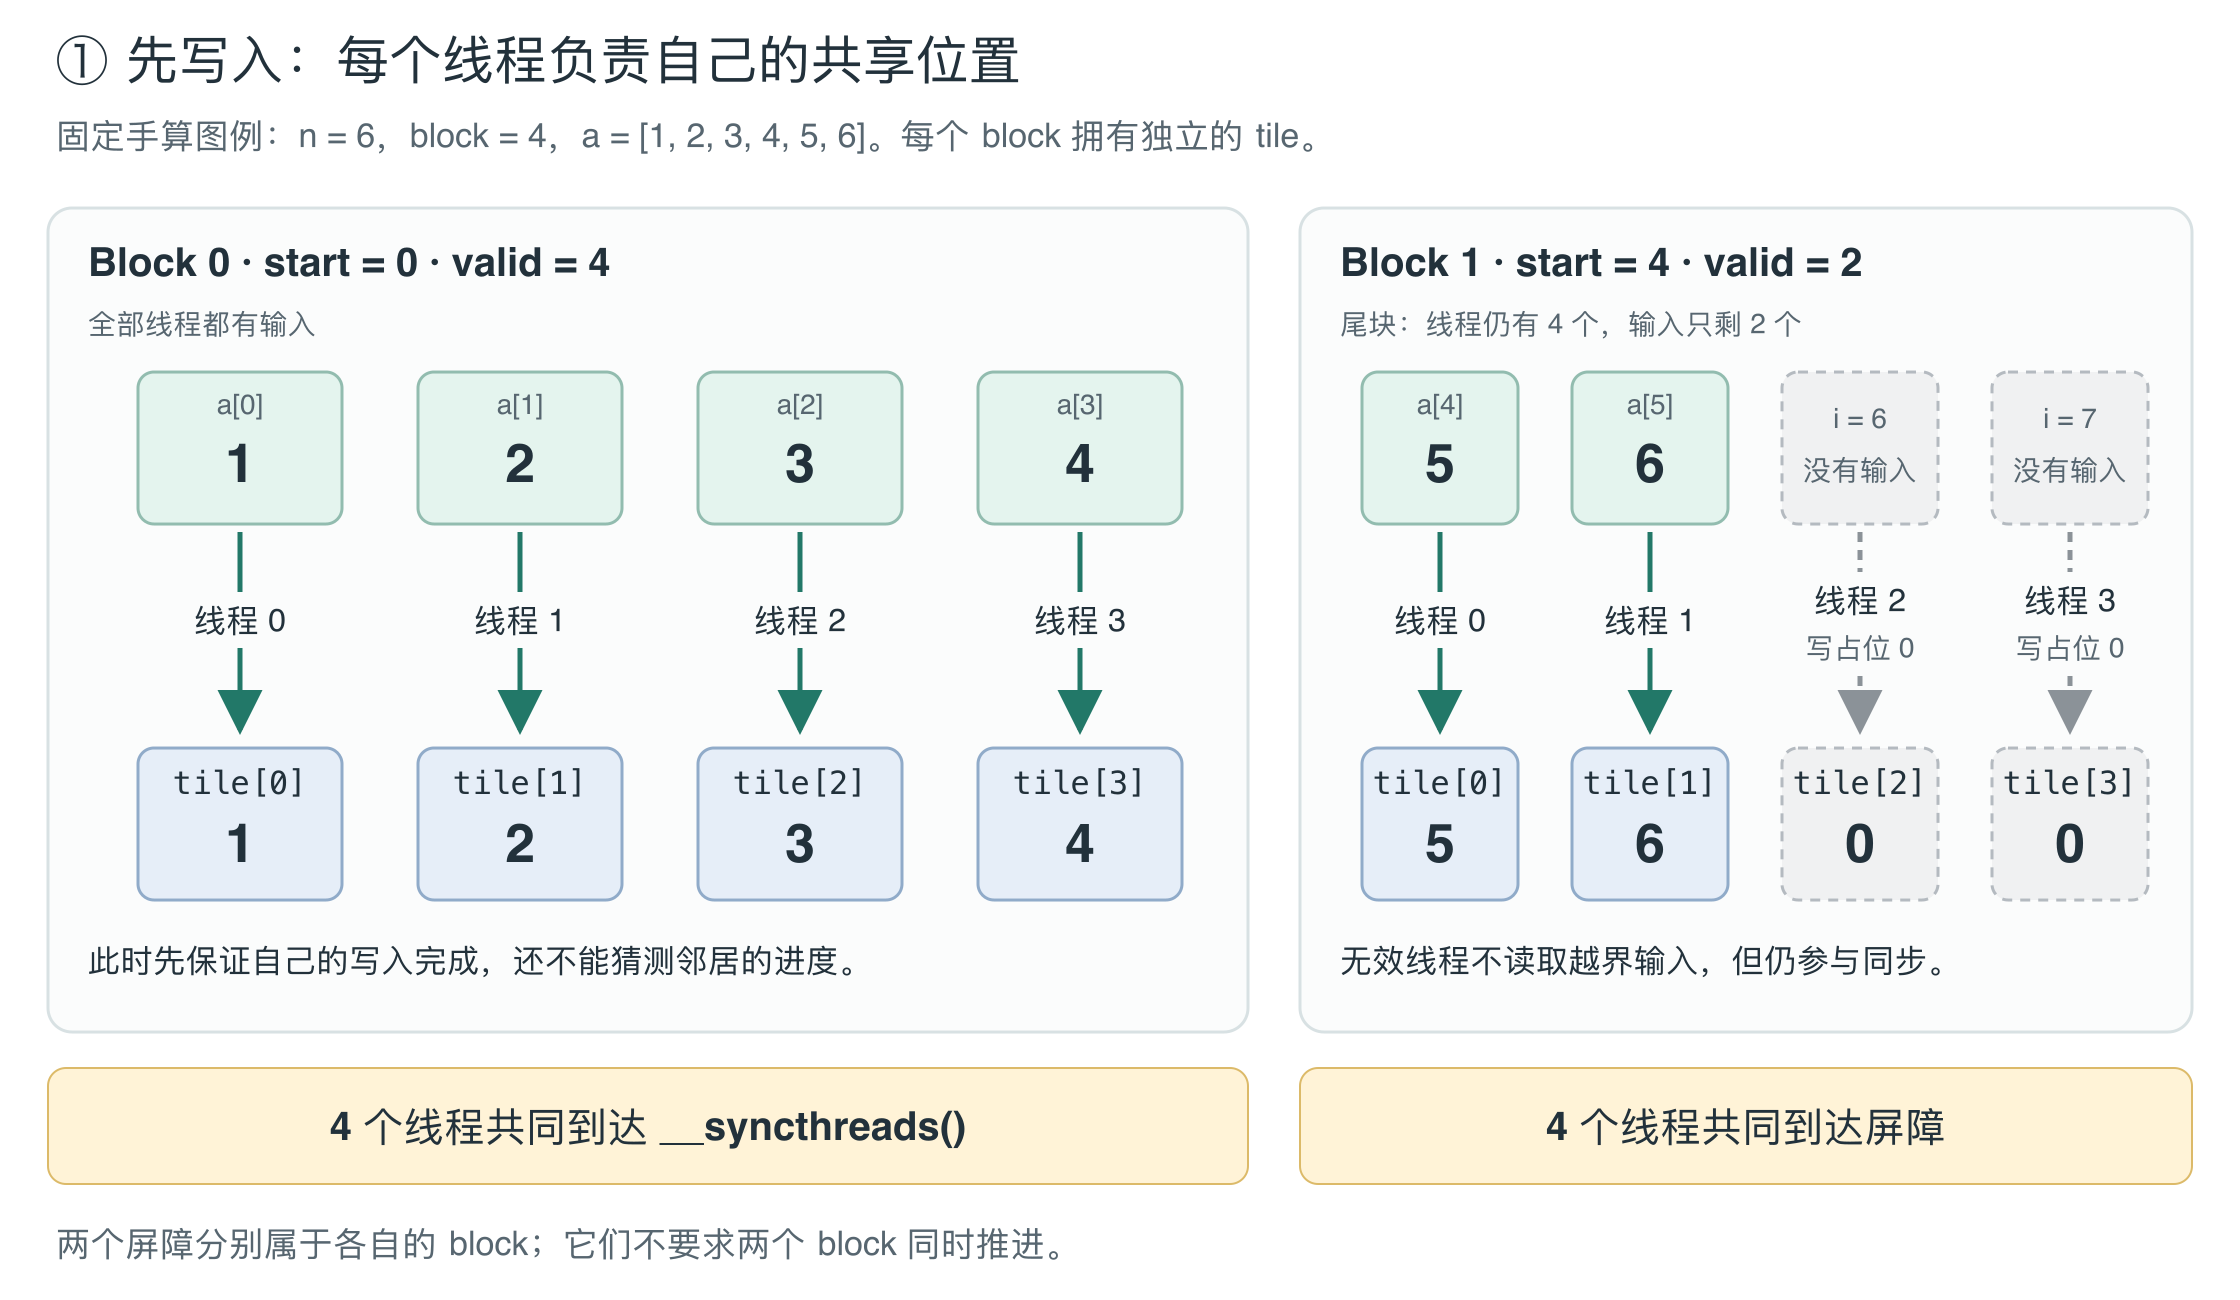

*固定图例的写入阶段：完整块写入 [1,2,3,4]，尾块写入 [5,6,0,0]；每个 block 的全部线程参加各自的屏障。*


**再读邻居的位置。**屏障后，完整块的四名线程分别读取 `tile[1]`、`tile[2]`、`tile[3]`、`tile[0]`，
得到 `[2,3,4,1]`，再分别加上原位置的 `[10,20,30,40]`。
尾块只有两个有效位置，因此只交换 5 与 6；有效线程不会读取占位 0，无效线程也不会写出结果。

请在下图中追踪线程 3 与尾块线程 1：它们都回到自己 block 的第一个有效位置，
不会跨 block 寻找邻居。两个 block 的共享数组彼此独立，屏障也不要求它们同时推进。


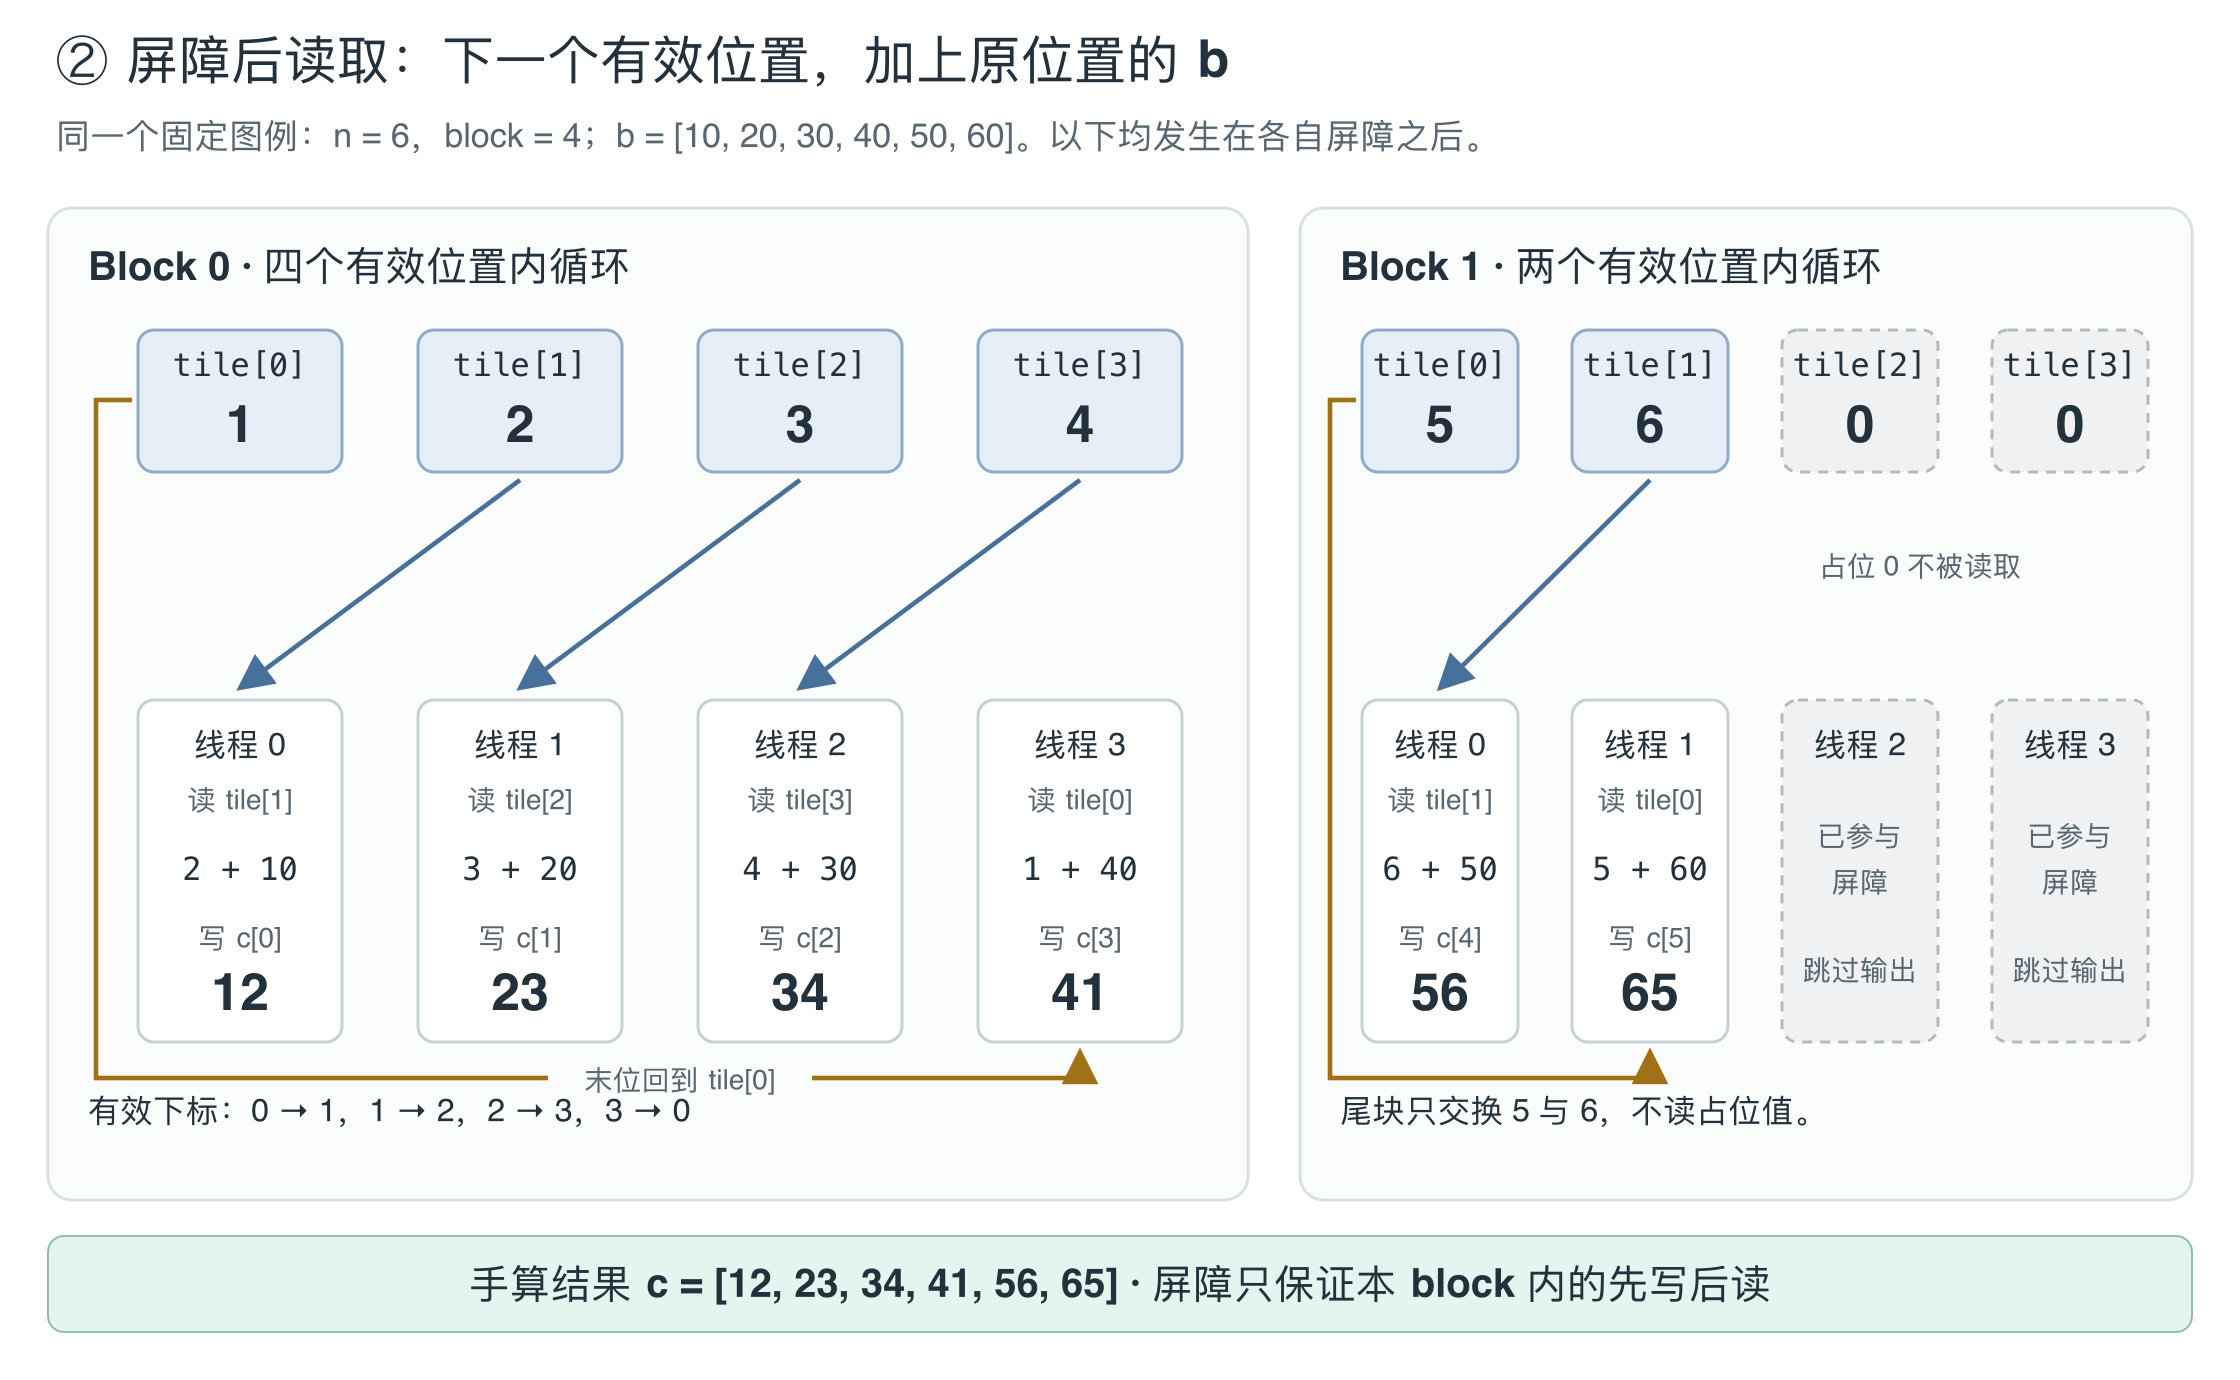

*固定图例的读取与计算：屏障后读取下一个有效共享位置，加上原位置的 b，手算得到 [12,23,34,41,56,65]。*


现在把图里的写入、屏障和邻居读取写成 kernel。`local_i` 是块内线程编号，
`start` 是当前块的数组起点；邻居下标始终在本块的 `valid` 个有效位置内循环。

这个 kernel 的共享数组容量由源码选为 1024 个 FP32 元素，因此本例要求 `block <= 1024`；
这只是本例容量约定，实际设备启动限制仍由运行层检查。没有假设固定 bank 数或 wavefront 大小。


In [ ]:
%%hip neighbor_add --preset binary_f32
__global__ void kernel(const float* a, const float* b, float* c, int n) {
    __shared__ float tile[1024];
    int local_i = threadIdx.x;
    int start = blockIdx.x * blockDim.x;
    int i = start + local_i;
    int valid = n - start;
    if (valid > blockDim.x) valid = blockDim.x;
    tile[local_i] = i < n ? a[i] : 0.0f;
    __syncthreads();
    if (i < n) {
        int neighbor = local_i + 1 < valid ? local_i + 1 : 0;
        c[i] = tile[neighbor] + b[i];
    }
}


请先找到屏障：它位于有效下标判断之外。尾块的无效线程也会写一个安全的占位值并到达屏障，
随后才跳过输出。把 `return` 放在无效线程处、让其提前离开共同屏障，不是正确的尾部处理。

先为数学规则写参考实现。下面通过下标计算得到每个位置应读取的邻居，和 HIP 的共享实现互相核对。


In [ ]:
def reference_neighbor(a, b, block):
    n = a.numel()
    i = torch.arange(n, device=a.device)
    start = (i // block) * block
    valid = torch.minimum(torch.full_like(i, block), n - start)
    neighbor = start + (i % block + 1) % valid
    return a[neighbor] + b

toy_a = torch.tensor([1., 2., 3., 4., 5., 6.], device="cuda")
toy_b = torch.tensor([10., 20., 30., 40., 50., 60.], device="cuda")
toy_out = neighbor_add(toy_a, toy_b, block=4)
torch.testing.assert_close(toy_out, reference_neighbor(toy_a, toy_b, 4), rtol=0, atol=0)
toy_out.cpu().tolist()


**观察**：把输出和图中的手算结果逐项核对。`c[3]` 使用的是 `a[0] + b[3]`，
`c[5]` 使用的是 `a[4] + b[5]`。尾块的最后一个有效线程回到自己这块的起点，
不会跨 block 去找下一块，也不会读到占位 0。LDS 与该屏障建立的是 block 内协作。


In [ ]:
n, block = cfg["n"], cfg["block"]
assert 1 <= block <= 1024, "本例的共享数组容量要求 block <= 1024"
checked = []
for length in (1, block - 1, block + 3, n + 3):
    a = torch.randn(length, device="cuda")
    b = torch.randn_like(a)
    actual = neighbor_add(a, b, block=block)
    expected = reference_neighbor(a, b, block)
    torch.testing.assert_close(actual, expected, rtol=0, atol=0)
    checked.append({"n": length, "correct": True})
pd.DataFrame(checked)


这里使用 LDS 是为了练习交接，而不是宣称它比直接读取邻居更快。
同样的数学任务也能让每个线程直接从全局内存读邻居；两种写法值得比较，但需要相同输入和测量口径。


## 3.4 访存等待与指令调度

一组工作在等待输入时，另一组已经准备好的指令可能继续执行。这叫延迟隐藏：
等待中的读取并没有因此提早返回，只是执行资源可以在这段时间处理别的工作。
保留更多工作也需要寄存器、LDS 等资源，所以“线程越多越好”并不成立。


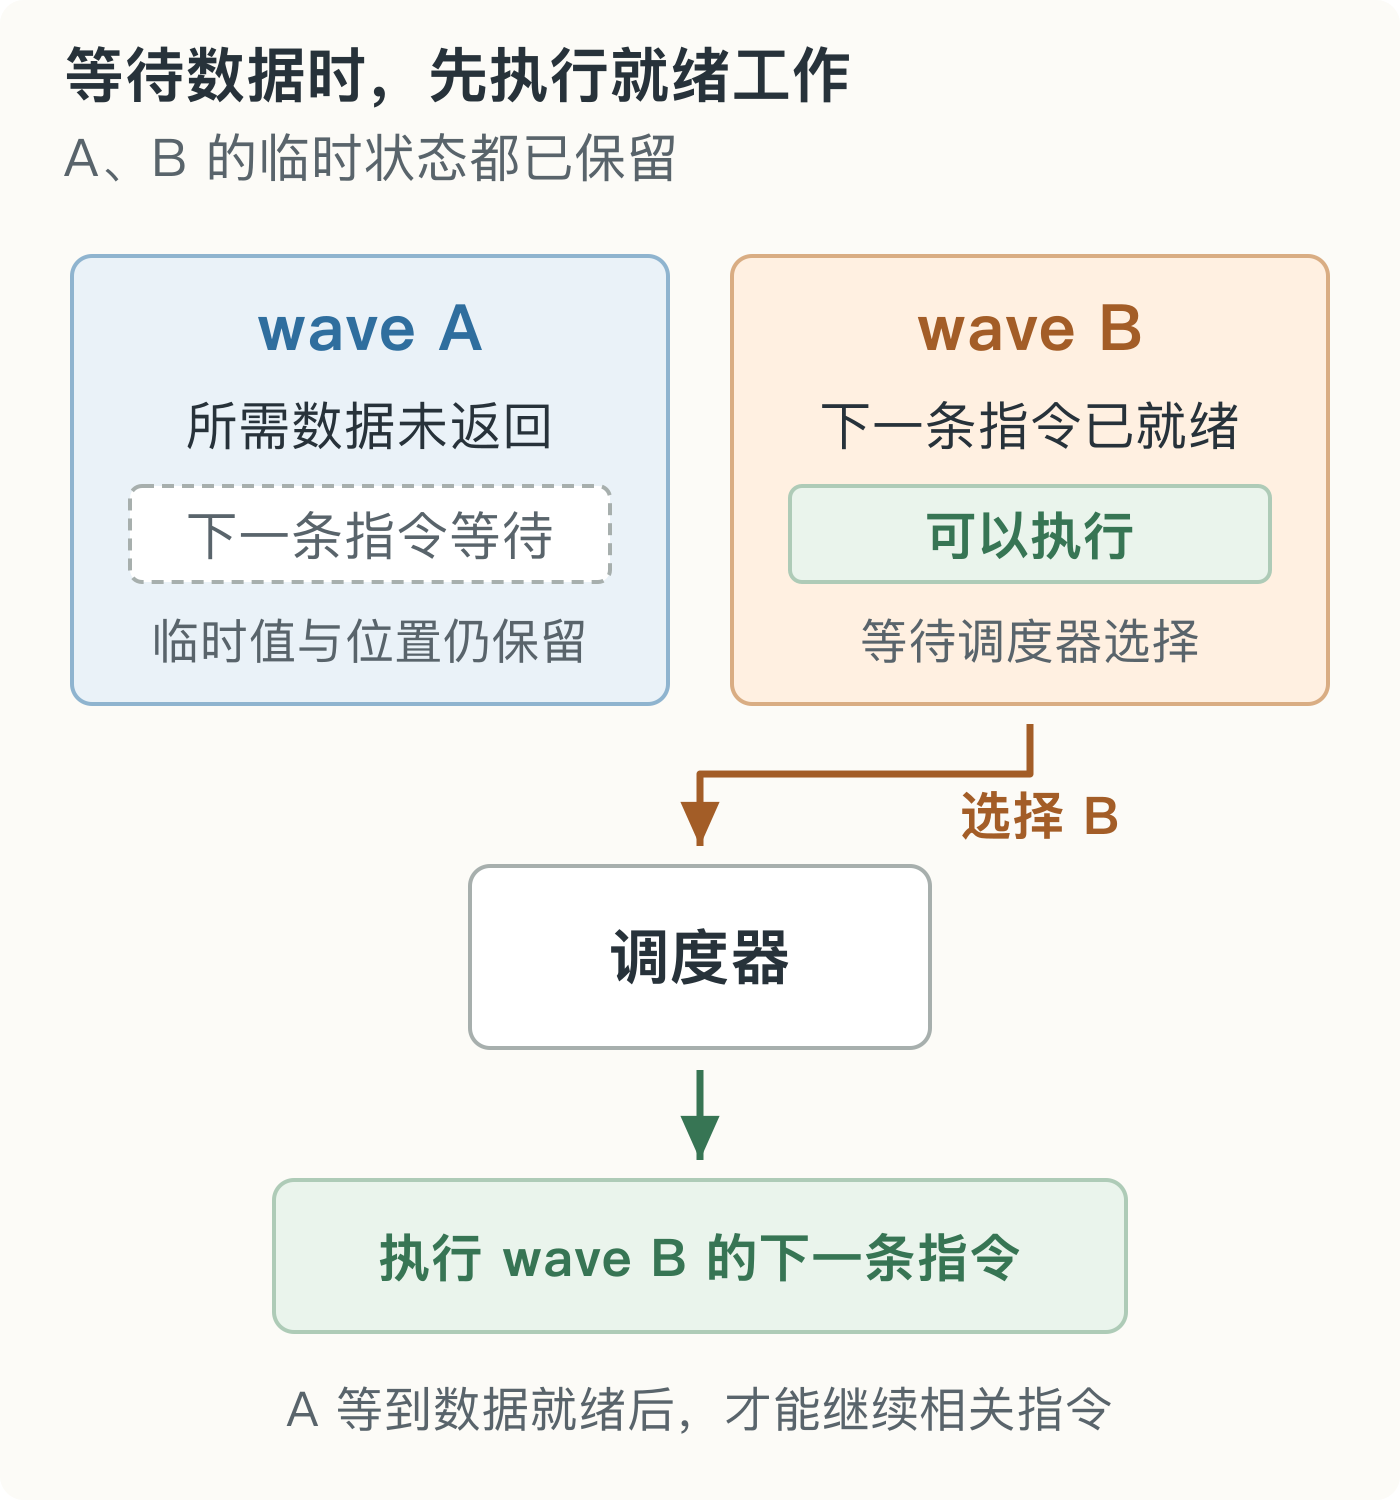

*等待中的状态仍被保留，调度器选择其他就绪工作；图不表示固定周期或顺序。*


我们先保存一份可供以后比较的测量。输入、输出、参考结果在计时前准备好，
计时只包含这次已准备调用的当前流 event 区间。它可以作为下一轮起点，
但单个时间不能证明 occupancy、缓存命中率或延迟隐藏是否充分。


In [ ]:
a = torch.randn(n, device="cuda")
b = torch.randn_like(a)
out = torch.empty_like(a)
run = neighbor_add.prepare(a, b, block=block, out=out)
run()
torch.testing.assert_close(out, reference_neighbor(a, b, block), rtol=0, atol=0)
measurement = gpu.benchmark(run, label="LDS neighbor add",
                            warmup=cfg["warmup"], repeat=cfg["repeat"])
gpu.summary([measurement])


In [ ]:
record = gpu.save_record("part0-intro/chapter3", kernel=neighbor_add,
    config={**cfg, "shape": [n], "dtype": "float32", "correct": True,
            "checked_lengths": [row["n"] for row in checked],
            "goal": "观察 block 内 LDS 写入、屏障与邻居读取",
            "entry": "chapter3.ipynb", "operation": "block-local left rotation of a plus b"},
    measurements=[measurement])
record


## 自我检验

1. 将小例子的长度改为 9、block 保持 4。手算最后一块的邻居是谁，再运行检查。
2. 写出直接读取全局内存邻居的版本，先与 `reference_neighbor` 对照，再公平比较两版时间。
3. 为什么把屏障放进 `if (i < n)` 内会破坏尾块的协作约定？不要通过故意运行错误同步来猜答案。
4. 图中的 wavefront A 等待时，B 可以推进。什么情况下 B 也不能推进？

## 进一步学习

LDS 的 bank、寄存器占用与矩阵专用指令都依赖具体目标和编译产物。
需要时再读[执行资源与访存实验](../../../docs/part0-intro/chapter3/experiments.md)，
先区分示意模型与实际采集数据。本章不为这些机制填入未经当前实验确认的固定数量。

## 本章小结

访问地址描述“读哪里”，共享存储描述“在哪里交接”，屏障描述“何时可以读”。
接下来到[第 4 章](../chapter4/chapter4.ipynb)，把正确计算与可信计时组织成一份完整实验。
